In [2]:
import pandas as pd
import numpy as np

# HW3 Part 1: Data Reading and Cleaning (20 points total)

Suppose you are interested in modeling the weather of the Great Lakes.  You find some great data in the [Great Lakes Weather Data and Marine Observations](https://apps.glerl.noaa.gov/marobs/) webpage that has been compiled by the [Great Lakes Environmental Research Laboratory](https://www.glerl.noaa.gov/about/), a lab that operates under NOAA.  This dataset has lots of information that might be helpful.  Let's check it out!

As you might recall from Day 12, data sometimes comes in formats that you might not be familiar with.  Figuring out how to load in the data in a useful way is one of the most common issues that you will face.  In the cell below, try reading in the data from `g202502600.lmd` using `read_csv`.  

In [5]:
# Run this cell!
problem_data = pd.read_csv('g202502600.lmd')
problem_data.head()

,202502600001AGCM4 29 999.9 999.9 999 99.9 99.9 999 9999.9 1015.4 0.1 99.9 99.9
0,202502600001ALXN6 59 999.9 999.9 999 99.9 99...
1,202502600001APNM4 29 -1.2 999.9 260 6.2 7...
2,202502600001BHRI3 19 2.5 999.9 270 5.7 7...
3,202502600001BIGM4 09 -2.4 999.9 330 3.6 7...
4,202502600001BSBM4 19 1.0 999.9 270 16.5 21...


## Part 1.1 - Evaluating Data (2 points)

You probably saw that data did not load correctly.  Open the data and take a look at the file.  You might also want to look at the format sheet that is provided on the website: https://apps.glerl.noaa.gov/marobs/docs/data.lmd.fmt. 

**Name at least two things about how the data is formatted that might make it hard for `read_csv` to read in the data.**

<font size=8 color="#009600">&#9998;</font> Put your answer here:  


### ANSWER ###
One point for each item listed, for max of 2 points
1. Separated by whitespace, not commas
2. Separation is variable size
3. The lines for ships have more info (the fields given by nn.nn and oo.oo at the end)

## Part 1.2 Loading Data (5 points)

It appears we might need to use a different tool to read in the data.  Take a look at the tools pandas has available, and read some of the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/io.html.  Is there one that looks like it might be useful in this case?  **Test out the tool you selected and print the first few rows to make sure it works.  Make sure the columns are appropriately named!**  

*If all goes well, you should get something that looks like this*

In [10]:
### ANSWER ###
colspecs = [(0,4), (4,7), (7,9), (9,11), (11,12), (12,20), (20,21), (21,22), (23,28),(29,34), (35,38), (39,43), (44,48), (49,53), (53,59), (60,66), (67,71), (72,76), (77,81), (82,87), (88,93)]
names = ['year', 'day', 'hour', 'minute', 'station type', 'station id', 'lake', 'data format', 'air temp', 'dew point', 'wind direction', 'wind speed', 'max gust', 'cloud', 'solar', 'pressure', 'water temp', 'wave height', 'wave period', 'ship lat', 'ship long']
data = pd.read_fwf('g202502600.lmd',header=None,colspecs=colspecs,names=names)
data.head()

# rubric:
# 2 point read_fwf
# 1 point appropriate columns
    # (can use colspecs or widths when loading in, 
    #  students might also load in and then change columns after loaded in)
# 1 point named columns
# 1 point print out first rows

,year,day,hour,minute,station type,station id,lake,data format,air temp,dew point,...,wind speed,max gust,cloud,solar,pressure,water temp,wave height,wave period,ship lat,ship long
0,2025,26,0,0,1,AGCM4,2.0,9,999.9,999.9,...,99.9,99.9,999,9999.9,1015.4,0.1,99.9,99.9,NaN,NaN
1,2025,26,0,0,1,ALXN6,5.0,9,999.9,999.9,...,99.9,99.9,999,9999.9,1017.0,1.3,99.9,99.9,NaN,NaN
2,2025,26,0,0,1,APNM4,2.0,9,-1.2,999.9,...,6.2,7.2,999,9999.9,9999.9,99.9,99.9,99.9,NaN,NaN
3,2025,26,0,0,1,BHRI3,1.0,9,2.5,999.9,...,5.7,7.7,999,9999.9,1020.3,99.9,99.9,99.9,NaN,NaN
4,2025,26,0,0,1,BIGM4,0.0,9,-2.4,999.9,...,3.6,7.2,999,9999.9,1008.8,99.9,99.9,99.9,NaN,NaN


## Part 1.3 Multiple Files (4 points)

Each file only includes data from a single day, which might not be very useful.  It would be much more useful to load in data from multiple days.  This is a very common thing to do in data science.  Fortunately, we can accomplish this in python!

**Write a `for` loop to load in the data from each of the files and save all of the data into one dataframe.  Print out the final dataframe.** In each iteration of the loop, you will change the name of the file to be loaded in.  Some starter code is provided to you to get you started, you will have to modify it.

In [12]:
# create an empty dataframe
# this is where all the data will eventually be stored
store_data = pd.DataFrame() 

# create a filename
filenumber = "{:03d}".format(3)
filename = "Example" + filenumber + ".csv"
print(filename)

# load in data to a temporary variable
temp_data = pd.read_csv(filename)

# add data to the storage variable 
store_data = pd.concat([store_data, temp_data])
store_data

Example003.csv


,A,B,C,D
0,10,8,3,6
1,4,5,3,8
2,12,15,6,2


In [13]:
### ANSWER ###

# create an empty dataframe
# this is where all the data will eventually be stored
store_data = pd.DataFrame() 

for i in range(26,57):
    # create a filename
    filenumber = "{:03d}".format(i)
    filename = "g2025" + filenumber + "00.lmd"
    print(filename)
    
    # load in data to a temporary variable
    temp_data = pd.read_fwf(filename,header=None,colspecs=colspecs,names=names)
    
    # add data to the storage variable 
    store_data = pd.concat([store_data, temp_data])

store_data

# Rubric:
# 1 point appropriate for loop
# 1 point change file name
# 1 point correct data 
# 1 point display 

g202502600.lmd
g202502700.lmd
g202502800.lmd
g202502900.lmd
g202503000.lmd
g202503100.lmd
g202503200.lmd
g202503300.lmd
g202503400.lmd
g202503500.lmd
g202503600.lmd
g202503700.lmd
g202503800.lmd
g202503900.lmd
g202504000.lmd
g202504100.lmd
g202504200.lmd
g202504300.lmd
g202504400.lmd
g202504500.lmd
g202504600.lmd
g202504700.lmd
g202504800.lmd
g202504900.lmd
g202505000.lmd
g202505100.lmd
g202505200.lmd
g202505300.lmd
g202505400.lmd
g202505500.lmd
g202505600.lmd


,year,day,hour,minute,station type,station id,lake,data format,air temp,dew point,...,wind speed,max gust,cloud,solar,pressure,water temp,wave height,wave period,ship lat,ship long
0,2025,26,0,0,1,AGCM4,2.0,9,999.9,999.9,...,99.9,99.9,999,9999.9,1015.4,0.1,99.9,99.9,NaN,NaN
1,2025,26,0,0,1,ALXN6,5.0,9,999.9,999.9,...,99.9,99.9,999,9999.9,1017.0,1.3,99.9,99.9,NaN,NaN
2,2025,26,0,0,1,APNM4,2.0,9,-1.2,999.9,...,6.2,7.2,999,9999.9,9999.9,99.9,99.9,99.9,NaN,NaN
3,2025,26,0,0,1,BHRI3,1.0,9,2.5,999.9,...,5.7,7.7,999,9999.9,1020.3,99.9,99.9,99.9,NaN,NaN
4,2025,26,0,0,1,BIGM4,0.0,9,-2.4,999.9,...,3.6,7.2,999,9999.9,1008.8,99.9,99.9,99.9,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17008,2025,56,23,56,6,TTF,4.0,9,7.0,1.0,...,3.1,99.9,0,9999.9,9999.9,99.9,99.9,99.9,NaN,NaN
17009,2025,56,23,56,6,VPZ,1.0,9,4.0,-1.0,...,2.6,99.9,0,9999.9,1012.3,99.9,99.9,99.9,NaN,NaN
17010,2025,56,23,57,6,MNM,1.0,9,4.0,-4.0,...,2.1,99.9,0,9999.9,1010.4,99.9,99.9,99.9,NaN,NaN
17011,2025,56,23,57,6,SUE,1.0,9,2.0,0.0,...,3.6,99.9,0,9999.9,1010.5,99.9,99.9,99.9,NaN,NaN


## Part 1.4 Statistics (1 point)

Now that you have 30 days worth of data loaded in, it is a good time to look at the data and see what you have.  Use the `.describe()` method on your dataset to get some statistics.

In [15]:
# your code here


In [16]:
### ANSWER
store_data.describe()
# 1 point

,year,day,hour,minute,station type,lake,data format,air temp,wind speed,max gust,cloud,solar,pressure,water temp,wave height,wave period,ship lat,ship long
count,517062.0,517062.000000,517062.000000,517062.000000,517062.000000,511130.000000,517062.0,517062.000000,517062.000000,517062.000000,517062.000000,5.170620e+05,517062.000000,517062.000000,517062.000000,517062.000000,5932.000000,5932.000000
mean,2025.0,41.085907,11.479308,27.382906,2.198522,2.015341,9.0,188.641409,30.241642,55.137313,806.679077,9.999900e+03,4615.300551,85.015318,99.860100,99.868739,44.018729,80.770212
std,0.0,8.939066,6.913900,19.016671,2.118890,1.684279,0.0,396.592512,42.228451,46.406104,378.034617,8.680226e-09,4401.217539,35.320614,1.989015,1.724021,1.739860,3.740696
min,2025.0,26.000000,0.000000,0.000000,0.000000,0.000000,9.0,-35.000000,0.000000,0.000000,0.000000,9.999900e+03,964.700000,0.000000,0.000000,2.000000,38.000000,73.000000
25%,2025.0,33.000000,5.000000,10.000000,1.000000,1.000000,9.0,-7.700000,3.100000,6.700000,999.000000,9.999900e+03,1016.400000,99.900000,99.900000,99.900000,43.000000,80.900000
50%,2025.0,41.000000,11.000000,30.000000,1.000000,2.000000,9.0,-3.400000,5.700000,99.900000,999.000000,9.999900e+03,1028.100000,99.900000,99.900000,99.900000,43.700000,82.400000
75%,2025.0,49.000000,17.000000,45.000000,1.000000,4.000000,9.0,3.000000,99.900000,99.900000,999.000000,9.999900e+03,9999.900000,99.900000,99.900000,99.900000,45.700000,83.000000
max,2025.0,56.000000,23.000000,59.000000,6.000000,6.000000,9.0,999.900000,99.900000,99.900000,999.000000,9.999900e+03,9999.900000,99.900000,99.900000,99.900000,46.500000,86.500000


## Part 1.5 Data Cleaning (4 points)

Take a look at the results from the describe function.  In particular, take a look at some of mean and max values, especially for air temperature.  Do those make sense to you?

**Part 1.5a**: You may have noticed there are a lot of places in the data that are filled with the digit 9.  **According to the [format guide](https://apps.glerl.noaa.gov/marobs/docs/data.lmd.fmt), what does this mean?**

**Part 1.5b**: Use the [`replace()` method](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.replace.html) in pandas to make these values something more suitable.

**Part 1.5c**: Does this make the values returned by `.describe()` make more sense?

In [18]:
### ANSWER
store_data_rmnan = store_data
store_data_rmnan = store_data_rmnan.replace(999.9,np.nan)
store_data_rmnan = store_data_rmnan.replace(99.9,np.nan)
store_data_rmnan = store_data_rmnan.replace(999,np.nan)
store_data_rmnan = store_data_rmnan.replace(9999.9,np.nan)
store_data_rmnan.describe()

# 1 point - 99999 means no value available
# 2 points - use replace appropriately - could use pd.NA instead of np.nan
# 1 point - describe values make more sense
# NOTE: certain columns (e.g. dew point, wind direction) may load into pandas as strings - that does not affect describe

,year,day,hour,minute,station type,lake,data format,air temp,wind speed,max gust,cloud,solar,pressure,water temp,wave height,wave period,ship lat,ship long
count,517062.0,517062.000000,517062.000000,517062.000000,517062.000000,511130.000000,517062.0,417341.000000,378520.000000,249727.000000,106534.000000,0.0,309433.000000,77992.000000,208.000000,170.000000,5932.000000,5932.000000
mean,2025.0,41.085907,11.479308,27.382906,2.198522,2.015341,9.0,-5.203715,4.746006,7.218453,65.571789,NaN,1017.921922,1.219319,0.712500,4.817647,44.018729,80.770212
std,0.0,8.939066,6.913900,19.016671,2.118890,1.684279,0.0,5.761620,3.147978,4.206349,42.915182,NaN,10.047526,1.329278,0.594124,1.590183,1.739860,3.740696
min,2025.0,26.000000,0.000000,0.000000,0.000000,0.000000,9.0,-35.000000,0.000000,0.000000,0.000000,NaN,964.700000,0.000000,0.000000,2.000000,38.000000,73.000000
25%,2025.0,33.000000,5.000000,10.000000,1.000000,1.000000,9.0,-8.800000,2.600000,4.100000,0.000000,NaN,1011.300000,0.100000,0.300000,4.000000,43.000000,80.900000
50%,2025.0,41.000000,11.000000,30.000000,1.000000,2.000000,9.0,-5.000000,4.100000,6.700000,100.000000,NaN,1018.800000,0.900000,0.500000,4.000000,43.700000,82.400000
75%,2025.0,49.000000,17.000000,45.000000,1.000000,4.000000,9.0,-1.500000,6.200000,9.800000,100.000000,NaN,1025.900000,1.700000,1.100000,6.000000,45.700000,83.000000
max,2025.0,56.000000,23.000000,59.000000,6.000000,6.000000,9.0,14.000000,71.000000,38.600000,100.000000,NaN,1080.300000,6.700000,2.500000,9.000000,46.500000,86.500000


## Part 1.6 - Masking (4 points)

Suppose you want to see if the weather on the west side of Lake Michigan is correlated with the weather on the east side of Lake Michigan.  

**Part 1.6a**: Choose three stations on the east side of Lake Michigan and three stations on the west side of Lake Michigan.  (Hint: Use the [map](https://apps.glerl.noaa.gov/marobs/php/data.php?sta=9&labels=n&param=5&units=e&zoom=m) to see where each station is located).  Which stations did you choose? (2 points)

**Part 1.6b**: Use masking to isolate data for each of those stations. (2 points)

In [20]:
### ANSWER ###

# west of L. Mich.
# chicago
data_CHI = store_data_rmnan[store_data_rmnan['station id']=='UGN']
data_CHI
# milwaukee
data_MKE = store_data_rmnan[store_data_rmnan['station id']=='MKE']
data_MKE
# sheboygan
data_SBM = store_data_rmnan[store_data_rmnan['station id']=='SBM']
data_SBM

# east of L. Mich.
# Holland
data_HOL = store_data_rmnan[store_data_rmnan['station id']=='BIV']
data_HOL
# Muskegon
data_MKG = store_data_rmnan[store_data_rmnan['station id']=='MKG']
data_MKG
# benton harbor
data_BEH = store_data_rmnan[store_data_rmnan['station id']=='BEH']
data_BEH

# rubric Part 1.6a
# 2/2 points - choosing 3 stations on each side
# 1/2 points - choosing less than 3 on each side

# rubric Part 1.6b
# 2/2 points - correct masking
# 1/2 points - attempt at masking but not successful

,year,day,hour,minute,station type,station id,lake,data format,air temp,dew point,...,wind speed,max gust,cloud,solar,pressure,water temp,wave height,wave period,ship lat,ship long
539,2025,26,0,53,6,BEH,1.0,9,2.0,-5.0,...,11.8,17.5,25.0,NaN,1019.7,NaN,NaN,NaN,NaN,NaN
1240,2025,26,1,53,6,BEH,1.0,9,2.0,-4.0,...,11.3,17.5,100.0,NaN,1020.2,NaN,NaN,NaN,NaN,NaN
1950,2025,26,2,53,6,BEH,1.0,9,2.0,-4.0,...,10.3,18.5,100.0,NaN,1020.7,NaN,NaN,NaN,NaN,NaN
2657,2025,26,3,53,6,BEH,1.0,9,1.0,-7.0,...,9.3,17.0,50.0,NaN,1021.8,NaN,NaN,NaN,NaN,NaN
3347,2025,26,4,53,6,BEH,1.0,9,0.0,-8.0,...,5.1,15.4,25.0,NaN,1022.8,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14101,2025,56,19,53,6,BEH,1.0,9,8.0,1.0,...,NaN,NaN,0.0,NaN,1010.7,NaN,NaN,NaN,NaN,NaN
14804,2025,56,20,53,6,BEH,1.0,9,8.0,0.0,...,3.6,NaN,0.0,NaN,1011.4,NaN,NaN,NaN,NaN,NaN
15508,2025,56,21,53,6,BEH,1.0,9,8.0,-1.0,...,2.6,NaN,0.0,NaN,1011.6,NaN,NaN,NaN,NaN,NaN
16208,2025,56,22,53,6,BEH,1.0,9,8.0,-1.0,...,2.1,NaN,0.0,NaN,1011.6,NaN,NaN,NaN,NaN,NaN


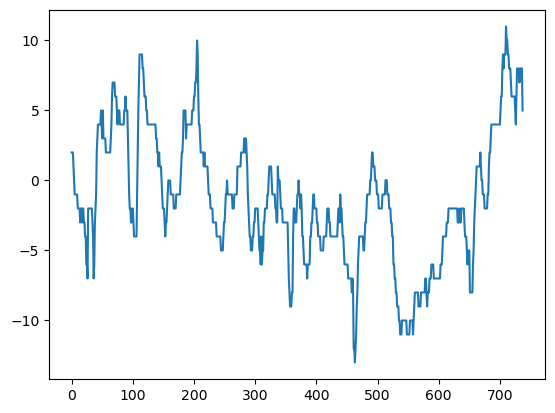

In [21]:
# just testing to see if it works...
import matplotlib.pyplot as plt
plt.plot(range(len(data_BEH['air temp'])),data_BEH['air temp'])